In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [16]:
df = pd.read_csv('/content/faults.csv')

In [17]:
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64
 15  Empt

In [19]:
df.isnull().sum()

,0
X_Minimum,0
X_Maximum,0
Y_Minimum,0
Y_Maximum,0
Pixels_Areas,0
X_Perimeter,0
Y_Perimeter,0
Sum_of_Luminosity,0
Minimum_of_Luminosity,0
Maximum_of_Luminosity,0


In [20]:
df.drop_duplicates()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,249,277,325780,325796,273,54,22,35033,119,141,...,-0.4286,0.0026,0.7254,0,0,0,0,0,0,1
1937,144,175,340581,340598,287,44,24,34599,112,133,...,-0.4516,-0.0582,0.8173,0,0,0,0,0,0,1
1938,145,174,386779,386794,292,40,22,37572,120,140,...,-0.4828,0.0052,0.7079,0,0,0,0,0,0,1
1939,137,170,422497,422528,419,97,47,52715,117,140,...,-0.0606,-0.0171,0.9919,0,0,0,0,0,0,1


In [21]:
X = df.drop(
    [
        'Pastry',
        'Z_Scratch',
        'K_Scatch',
        'Stains',
        'Dirtiness',
        'Bumps',
        'Other_Faults'
    ],
    axis=1
)
Y = df['Pastry']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [28]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9126


In [24]:
X_train

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
1917,154,169,260124,260136,75,27,17,9948,125,143,...,0.0110,0.5556,0.7059,0.0,1.8751,1.1761,1.0792,-0.2000,0.0362,0.3068
808,1121,1128,1789332,1789337,17,9,6,2240,115,150,...,0.0052,0.7778,0.8333,0.0,1.2305,0.8451,0.6990,-0.2857,0.0294,0.1441
680,41,216,2708878,2708939,6298,275,134,654634,42,126,...,0.1289,0.6364,0.4552,0.0,3.7992,2.2430,1.7853,-0.6514,-0.1879,1.0000
534,129,157,86408,86427,276,39,26,33858,115,135,...,0.0206,0.7179,0.7308,0.0,2.4409,1.4472,1.2787,-0.3214,-0.0416,0.8223
192,436,442,530968,530985,63,17,17,6374,90,116,...,0.0044,0.3529,1.0000,1.0,1.7993,0.7782,1.2305,0.6471,-0.2096,0.2083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,1192,1205,521912,521925,101,22,13,11601,108,125,...,0.0096,0.5909,1.0000,0.5,2.0043,1.1139,1.1139,0.0000,-0.1027,0.2914
1294,14,24,149048,149070,150,12,22,17566,99,140,...,0.0059,0.8333,1.0000,1.0,2.1761,1.0000,1.3424,0.5454,-0.0851,0.3663
860,615,622,2188217,2188232,57,13,15,6560,107,127,...,0.0051,0.5385,1.0000,1.0,1.7559,0.8451,1.1761,0.5333,-0.1009,0.2116
1459,220,229,3094414,3094424,54,10,10,6091,104,124,...,0.0053,0.9000,1.0000,1.0,1.7324,0.9542,1.0000,0.1000,-0.1188,0.1954


In [26]:
new_plate = [X.iloc[0]]

prediction = model.predict(new_plate)

print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


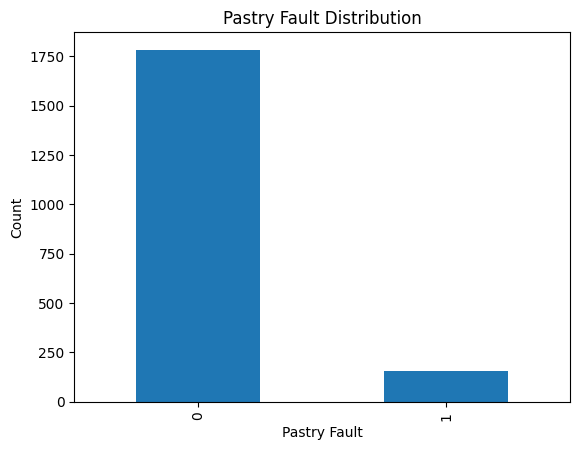

In [32]:
import matplotlib.pyplot as plt

df['Pastry'].value_counts().plot(kind='bar')

plt.title("Pastry Fault Distribution")
plt.xlabel("Pastry Fault")
plt.ylabel("Count")

plt.show()

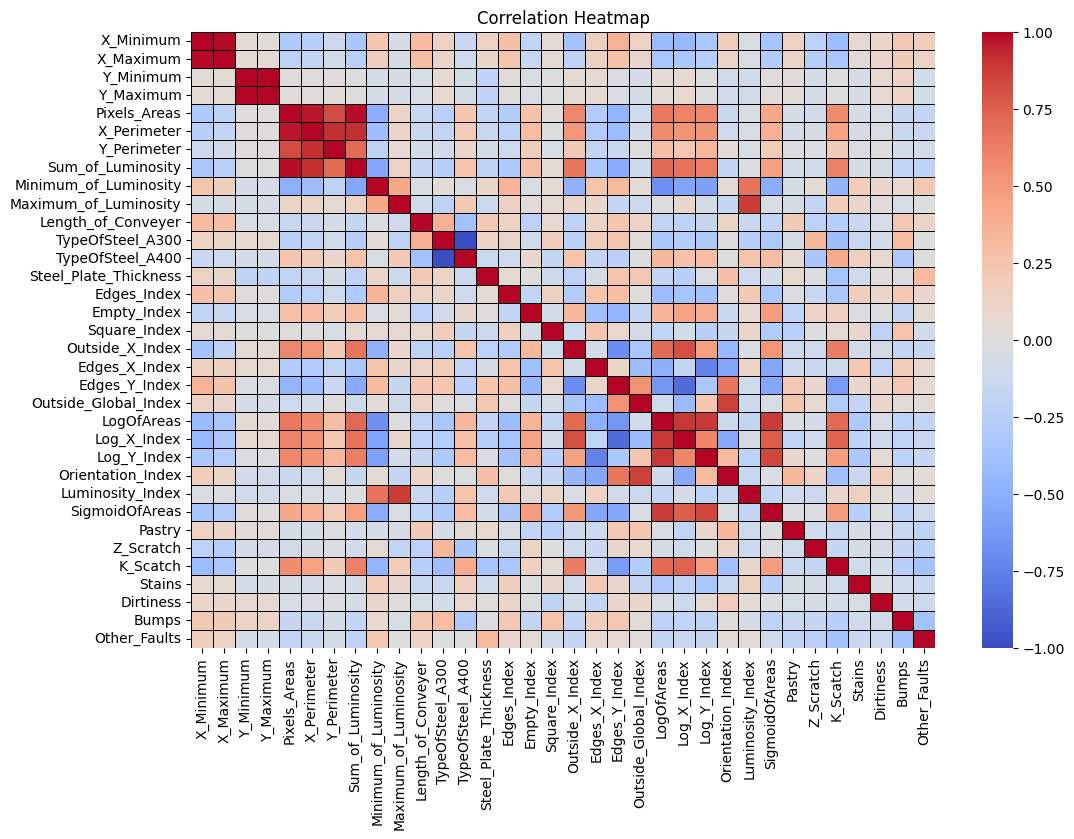

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',annot=False
    ,
    linewidths=0.5,
    linecolor='black'
)

plt.title("Correlation Heatmap")

plt.show()

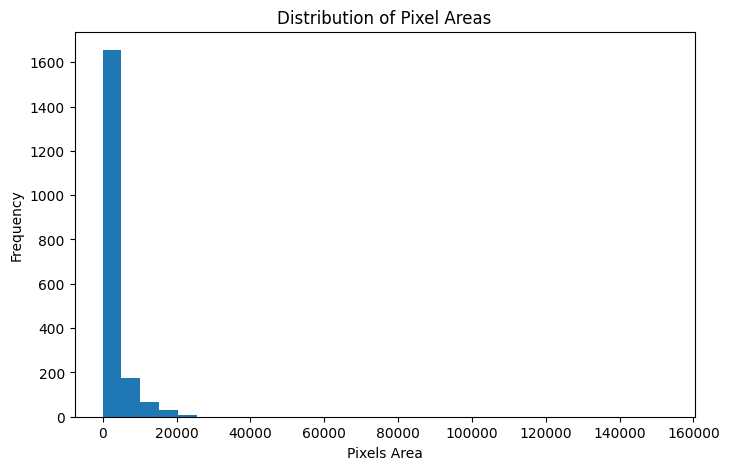

In [36]:
plt.figure(figsize=(8,5))

plt.hist(df['Pixels_Areas'], bins=30)

plt.title("Distribution of Pixel Areas")
plt.xlabel("Pixels Area")
plt.ylabel("Frequency")

plt.show()

Why Logistic Regression?

Because the model predicts:

Will the steel plate have a Pastry fault?

YES or NO

or

0 or 1

This is a binary classification problem.

Logistic Regression is specifically designed for:

Yes / No
True / False
Pass / Fail
Fraud / Not Fraud
Defective / Not Defective
Why Not Linear Regression?

Linear Regression predicts continuous values such as:

Price = ₹50,000
Temperature = 32.5°C
Sales = 1200
PredictedHours = 1461.8

It can produce outputs like:

1.73
-0.42
2.15

But for Pastry fault prediction, valid outputs are only:

0
1

So Linear Regression is not suitable.